In [109]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

In [110]:
import sys
print(sys.executable)

c:\Users\chent\Desktop\我的資料夾\學校\大學\三下\統計方法與資料採礦\DataMiningG1FinalProject\.venv\Scripts\python.exe


In [111]:
import pandas as pd
import os


if not os.path.exists(r"C:\Users\chent\.cache\kagglehub\datasets\shree0910\buy-now-and-pay-later-fintech-ml-dataset\versions\2\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv"):
    import kagglehub
    from getpass import getpass

    # 1. 使用 Kaggle Access Token 進行身份驗證
    print("🔐 Kaggle 身份驗證")
    print("-" * 40)

    # 方法：使用 Access Token 設定環境變數
    username = input("請輸入您的 Kaggle 用戶名: ").strip()
    access_token = getpass("請輸入您的 Kaggle Access Token (輸入不會顯示): ")

    # 2. 設定環境變數
    os.environ["KAGGLE_USERNAME"] = username
    os.environ["KAGGLE_KEY"] = access_token
    
    # 3. 下載資料集
    try:
        print("\n📥 正在下載資料集...")
        path = kagglehub.dataset_download("shree0910/buy-now-and-pay-later-fintech-ml-dataset")
        print(f"✅ 資料集實際存放在：{path}")
        print("-" * 40)
        
        # 4. 在下載的資料夾中尋找 CSV 檔案
        csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
        
        if csv_files:
            # 組合出完整的 CSV 檔案路徑
            file_path = os.path.join(path, csv_files[0])
            print(f"準備讀取檔案：{file_path}\n" + "-"*40)
            
            # 5. 使用 Pandas 讀取資料
            df = pd.read_csv(file_path)
            print(f"✅ 資料集已成功載入")
            print(f"資料形狀: {df.shape}")
            
            # 6. 顯示前五筆資料
            print("\n資料預覽:")
            display(df.head())
            
        else:
            print("⚠️ 在這個資料夾中沒有找到 CSV 檔案")
    except Exception as e:
        print(f"❌ 下載資料集時出錯: {e}")
        print("請確認用戶名和 Access Token 正確")
        raise
else:
    df = pd.read_csv(r"C:\Users\chent\.cache\kagglehub\datasets\shree0910\buy-now-and-pay-later-fintech-ml-dataset\versions\2\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")

## 第一階段：探索性資料分析 (EDA)
EDA 的目的是先探索資料，了解欄位型態、分佈與缺失情況，為後續預處理做準備。

In [112]:
# 1. 顯示資料集基本形狀
print("資料筆數與欄位數:", df.shape)

# 2. 欄位型態與 non-null 數量
print("\n欄位型態與非空值數量:")
df.info()

# 3. 缺失值檢查
print("\n缺失值統計:")
display(df.isna().sum())

# 4. 重複資料檢查
print("\n重複資料筆數:", df.duplicated().sum())

# 5. 基本統計摘要（數值與類別欄位）
print("\n數值欄位摘要:")
display(df.describe())

print("\n所有欄位摘要:")
display(df.describe(include='all').T)


資料筆數與欄位數: (10345, 17)

欄位型態與非空值數量:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-nul

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64


重複資料筆數: 0

數值欄位摘要:


,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000



所有欄位摘要:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10345.0,NaN,NaN,NaN,5173.0,2986.488601,1.0,2587.0,5173.0,7759.0,10345.0
age,10345.0,NaN,NaN,NaN,38.559884,12.131789,18.0,28.0,39.0,49.0,59.0
employment_type,10345,4,Salaried,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income,10345.0,NaN,NaN,NaN,35053.381898,27084.517277,5000.0,12207.02,23800.52,55276.93,145767.12
credit_score,10345.0,NaN,NaN,NaN,448.176124,136.518332,300.0,332.0,403.0,547.0,850.0
purchase_amount,10345.0,NaN,NaN,NaN,3979.402721,1500.828483,100.0,2990.72,5000.0,5000.0,5000.0
product_category,10345,5,Fashion,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bnpl_installments,10345.0,NaN,NaN,NaN,7.477525,3.362867,3.0,3.0,9.0,9.0,12.0
repayment_delay_days,10345.0,NaN,NaN,NaN,8.742774,6.781849,0.0,2.0,9.0,14.0,33.0
missed_payments,10345.0,NaN,NaN,NaN,1.01595,0.996726,0.0,0.0,1.0,2.0,7.0


# 📋 Column Guide

| Column | Type | Description |
|--------|------|-------------|
| user_id | int | Unique user identifier |
| age | int | User age (18–59) |
| employment_type | str | Salaried / Self-Employed / Student / Unemployed |
| monthly_income | float | Monthly income in USD |
| credit_score | int | Standard credit score (300–850) |
| purchase_amount | float | BNPL transaction value in USD |
| product_category | str | Electronics, Fashion, Sports, Home, Beauty |
| bnpl_installments | int | Number of repayment installments (3, 6, 9, 12) |
| repayment_delay_days | int | Days delayed beyond due date (0–33) |
| missed_payments | int | Total missed payments (0–7) |
| default_flag | int | Target: 1 = Defaulted, 0 = Paid ✅ |
| app_usage_frequency | float | App opens per week |
| location | str | Country (USA, India, UK, Germany, Canada, Australia) |
| transaction_date | str | Date of purchase (YYYY-MM-DD) |
| debt_to_income_ratio | float | DTI ratio (monthly debt / monthly income) |
| risk_score | float | Composite risk score (0–398) — higher = more risky |
| customer_segment | str | Low Risk / Medium Risk / High Risk |


## 統計學資料型態分類
資料型態可分為：
- **Categorical (類別型)**: 名目型 (nominal) - 無順序，如 employment_type, product_category, location
- **Ordinal (順序型)**: 有順序但間距不明確，如 customer_segment (風險等級: Low Risk / Medium Risk / High Risk)
- **Interval (區間型)**: 有等間距但無絕對零點，如 credit_score (信用分數), transaction_date
- **Ratio (比率型)**: 有絕對零點，可比較倍數，如 age, monthly_income, purchase_amount 等數值欄位

以下根據欄位內容進行分類：

In [113]:
# 根據統計學分類欄位
data_types = {
    'Categorical': ['employment_type', 'product_category', 'location', 'default_flag'],  # user_id 不需要
    'Ordinal': ['customer_segment'],  # 視為風險等級
    'Interval': ['credit_score', 'transaction_date'],  # 有等間距但無絕對零點的欄位
    'Ratio': ['age', 'monthly_income', 'purchase_amount', 'bnpl_installments', 
                      'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 
                      'debt_to_income_ratio', 'risk_score']  
}

## 根據資料型態的統計摘要
不同資料型態適合的統計量不同：
- **Categorical**: 總數、唯一值、最常見值
- **Ordinal**: 總數、平均、中位數、眾數、最小最大（如 customer_segment）
- **Interval**: 總數、平均、中位數、眾數、最小最大、標準差（如 credit_score）
- **Ratio**: 完整統計摘要（平均、標準差等）
- **日期時間型**: 時間範圍、格式檢查

=== Categorical 欄位統計 ===

employment_type:
  類別數量: 4
  眾數: Salaried (出現 2632 次)
  所有值: {'Salaried': 2632, 'Unemployed': 2632, 'Self-Employed': 2550, 'Student': 2531}

  各類別比例:
    Salaried: 2632 (25.4%)
    Unemployed: 2632 (25.4%)
    Self-Employed: 2550 (24.6%)
    Student: 2531 (24.5%)


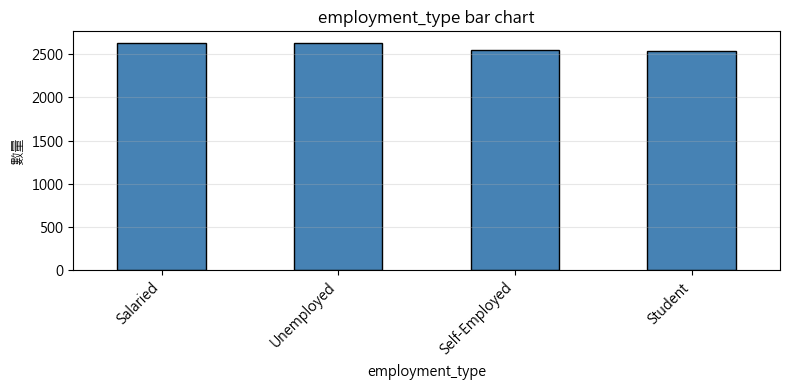


product_category:
  類別數量: 5
  眾數: Fashion (出現 2166 次)
  所有值: {'Fashion': 2166, 'Electronics': 2085, 'Beauty': 2072, 'Home': 2052, 'Sports': 1970}

  各類別比例:
    Fashion: 2166 (20.9%)
    Electronics: 2085 (20.2%)
    Beauty: 2072 (20.0%)
    Home: 2052 (19.8%)
    Sports: 1970 (19.0%)


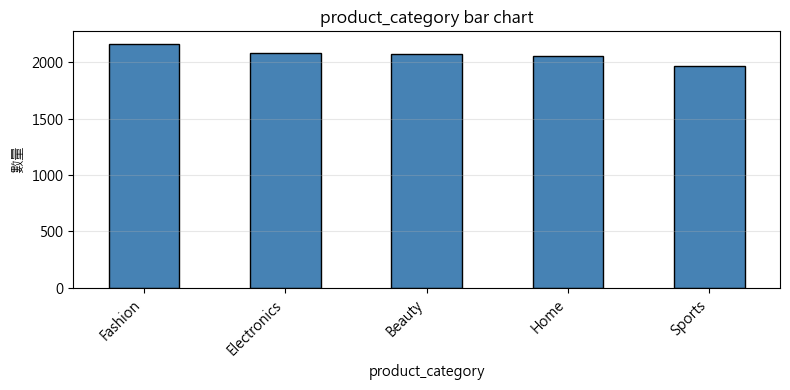


location:
  類別數量: 6
  眾數: Germany (出現 1760 次)
  所有值: {'Germany': 1760, 'Canada': 1740, 'USA': 1736, 'India': 1723, 'Australia': 1722, 'UK': 1664}

  各類別比例:
    Germany: 1760 (17.0%)
    Canada: 1740 (16.8%)
    USA: 1736 (16.8%)
    India: 1723 (16.7%)
    Australia: 1722 (16.6%)
    UK: 1664 (16.1%)


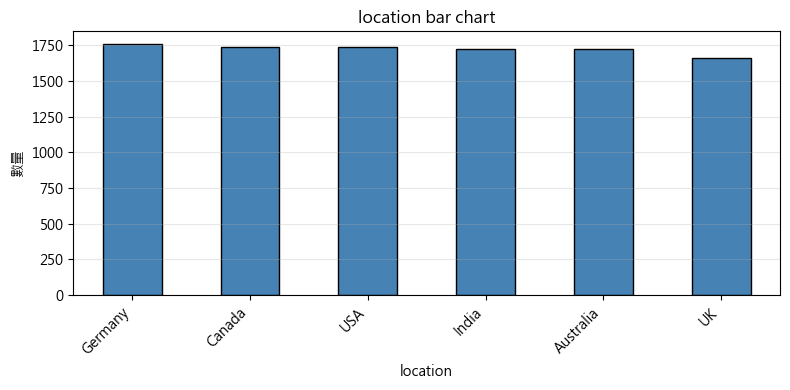


default_flag:
  類別數量: 2
  眾數: 0 (出現 6305 次)
  所有值: {0: 6305, 1: 4040}

  各類別比例:
    0: 6305 (60.9%)
    1: 4040 (39.1%)


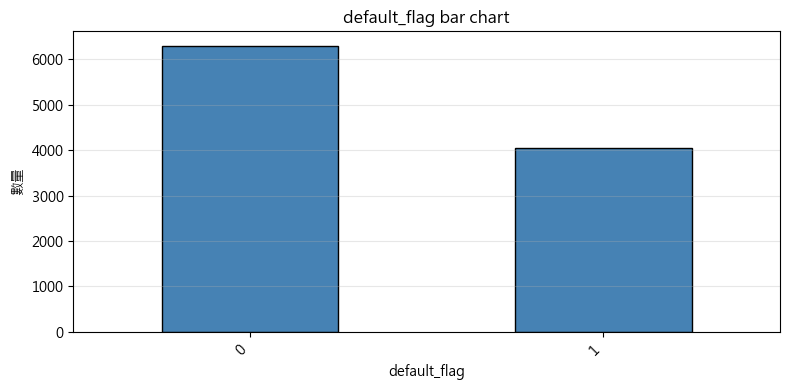

In [114]:
# Categorical統計
print("=== Categorical 欄位統計 ===")
for col in data_types['Categorical']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  類別數量: {df[col].nunique()}")
        print(f"  眾數: {df[col].mode().iloc[0]} (出現 {df[col].value_counts().iloc[0]} 次)")
        print(f"  所有值: {df[col].value_counts().to_dict()}")
        
        # 計算各類別的比例
        print(f"\n  各類別比例:")
        value_counts = df[col].value_counts()
        total_count = len(df[col])
        for category, count in value_counts.items():
            percentage = (count / total_count) * 100
            print(f"    {category}: {count} ({percentage:.1f}%)")
        
        # 畫長條圖
        plt.figure(figsize=(8, 4))
        df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
        plt.title(f"{col} bar chart")
        plt.xlabel(col)
        plt.ylabel('數量')
        plt.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

=== Ordinal 欄位統計 ===
Ordinal 欄位清單: ['customer_segment']
資料集欄位包含 Ordinal 欄位: ['customer_segment']

customer_segment:
  數值映射: {'Low Risk': 1, 'Medium Risk': 2, 'High Risk': 3}
  總數: 10345
  中位數: 3.00
  眾數: 3
  最小值: 1
  最大值: 3

  各類別比例:
    High Risk: 7569 (73.2%)
    Medium Risk: 2200 (21.3%)
    Low Risk: 576 (5.6%)


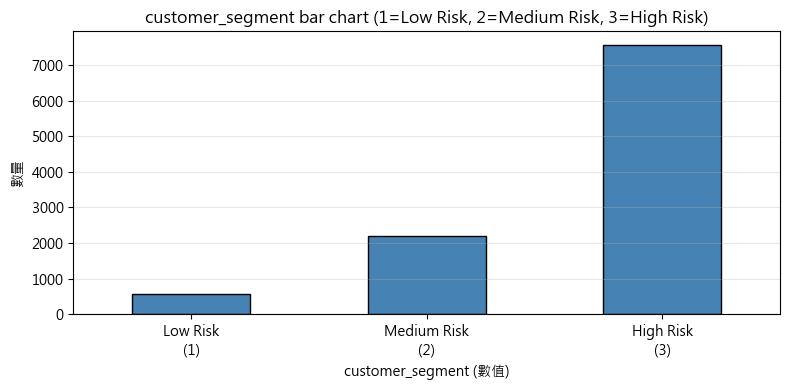

In [115]:
# Ordinal 統計
print("=== Ordinal 欄位統計 ===")
print(f"Ordinal 欄位清單: {data_types['Ordinal']}")
print(f"資料集欄位包含 Ordinal 欄位: {[col for col in data_types['Ordinal'] if col in df.columns]}")

# 定義 customer_segment 的順序映射
segment_mapping = {'Low Risk': 1, 'Medium Risk': 2, 'High Risk': 3}

for col in data_types['Ordinal']:
    if col in df.columns:
        print(f"\n{col}:")
        
        # 特殊處理 customer_segment：轉換為數值
        if col == 'customer_segment':
            df_numeric = df[col].map(segment_mapping)
            print(f"  數值映射: {segment_mapping}")
            print(f"  總數: {df_numeric.count()}")
            print(f"  中位數: {df_numeric.median():.2f}")
            print(f"  眾數: {df_numeric.mode().iloc[0]}")
            print(f"  最小值: {df_numeric.min()}")
            print(f"  最大值: {df_numeric.max()}")
            
            # 計算各類別的比例
            print(f"\n  各類別比例:")
            value_counts = df[col].value_counts()
            total_count = len(df[col])
            for category, count in value_counts.items():
                percentage = (count / total_count) * 100
                print(f"    {category}: {count} ({percentage:.1f}%)")
            
            # 畫長條圖（使用數值版本）
            plt.figure(figsize=(8, 4))
            df_numeric.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
            plt.title(f"{col} bar chart (1=Low Risk, 2=Medium Risk, 3=High Risk)")
            plt.xlabel(f"{col} (數值)")
            plt.ylabel('數量')
            plt.xticks([0, 1, 2], ['Low Risk\n(1)', 'Medium Risk\n(2)', 'High Risk\n(3)'], rotation=0)
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()    

=== Interval 欄位統計 (非時間型) ===
Interval 欄位清單: ['credit_score', 'transaction_date']
資料集欄位包含 Interval 欄位: ['credit_score', 'transaction_date']

credit_score:
  總數: 10345
  平均: 448.18
  中位數: 403.00
  眾數: 300
  最小值: 300
  最大值: 850
  標準差: 136.52


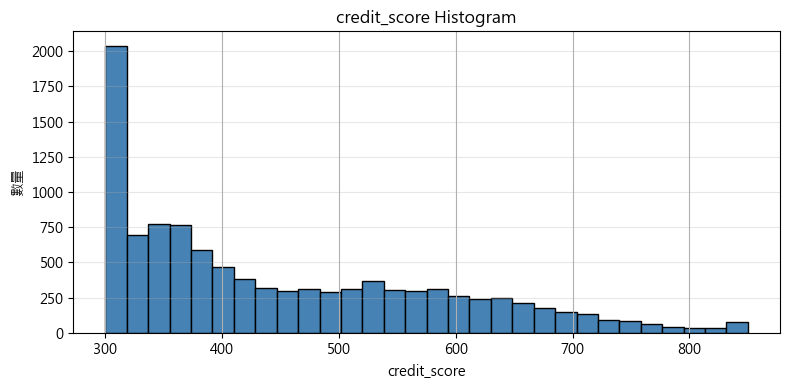

In [116]:
# Interval 統計 (非時間型)
print("=== Interval 欄位統計 (非時間型) ===")
print(f"Interval 欄位清單: {data_types['Interval']}")
print(f"資料集欄位包含 Interval 欄位: {[col for col in data_types['Interval'] if col in df.columns]}")

for col in data_types['Interval']:
    if col in df.columns and col != 'transaction_date':  # transaction_date 在下面單獨處理
        print(f"\n{col}:")
        print(f"  總數: {df[col].count()}")
        print(f"  平均: {df[col].mean():.2f}")
        print(f"  中位數: {df[col].median():.2f}")
        print(f"  眾數: {df[col].mode().iloc[0]}")
        print(f"  最小值: {df[col].min()}")
        print(f"  最大值: {df[col].max()}")
        print(f"  標準差: {df[col].std():.2f}")
        
        # 畫直方圖
        plt.figure(figsize=(8, 4))
        df[col].hist(bins=30, color='steelblue', edgecolor='black')
        plt.title(f"{col} Histogram")
        plt.xlabel(col)
        plt.ylabel('數量')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

=== 時間型 Interval 統計與特徵工程 ===
非時間型 Interval 欄位 'credit_score' 在其他地方處理

transaction_date:
  總數: 10345
  開始時間: 2023-01-01 00:00:00
  結束時間: 2024-12-31 00:00:00
  時間跨度: 730 天
  缺失值: 0

  提取的特徵:
    - transaction_date_year
    - transaction_date_month
    - transaction_date_day
    - transaction_date_dayofweek (0=Monday, 6=Sunday)
    - transaction_date_is_weekend (1=Weekend, 0=Weekday)

  各時間特徵比例:

    transaction_date_year:
      2023: 5145 (49.7%)
      2024: 5200 (50.3%)

    transaction_date_month:
      1月: 899 (8.7%)
      2月: 823 (8.0%)
      3月: 895 (8.7%)
      4月: 858 (8.3%)
      5月: 808 (7.8%)
      6月: 862 (8.3%)
      7月: 874 (8.4%)
      8月: 868 (8.4%)
      9月: 876 (8.5%)
      10月: 853 (8.2%)
      11月: 868 (8.4%)
      12月: 861 (8.3%)

    transaction_date_dayofweek:
      Monday: 1481 (14.3%)
      Tuesday: 1514 (14.6%)
      Wednesday: 1462 (14.1%)
      Thursday: 1476 (14.3%)
      Friday: 1480 (14.3%)
      Saturday: 1410 (13.6%)
      Sunday: 1522 (14.7%)

    transac

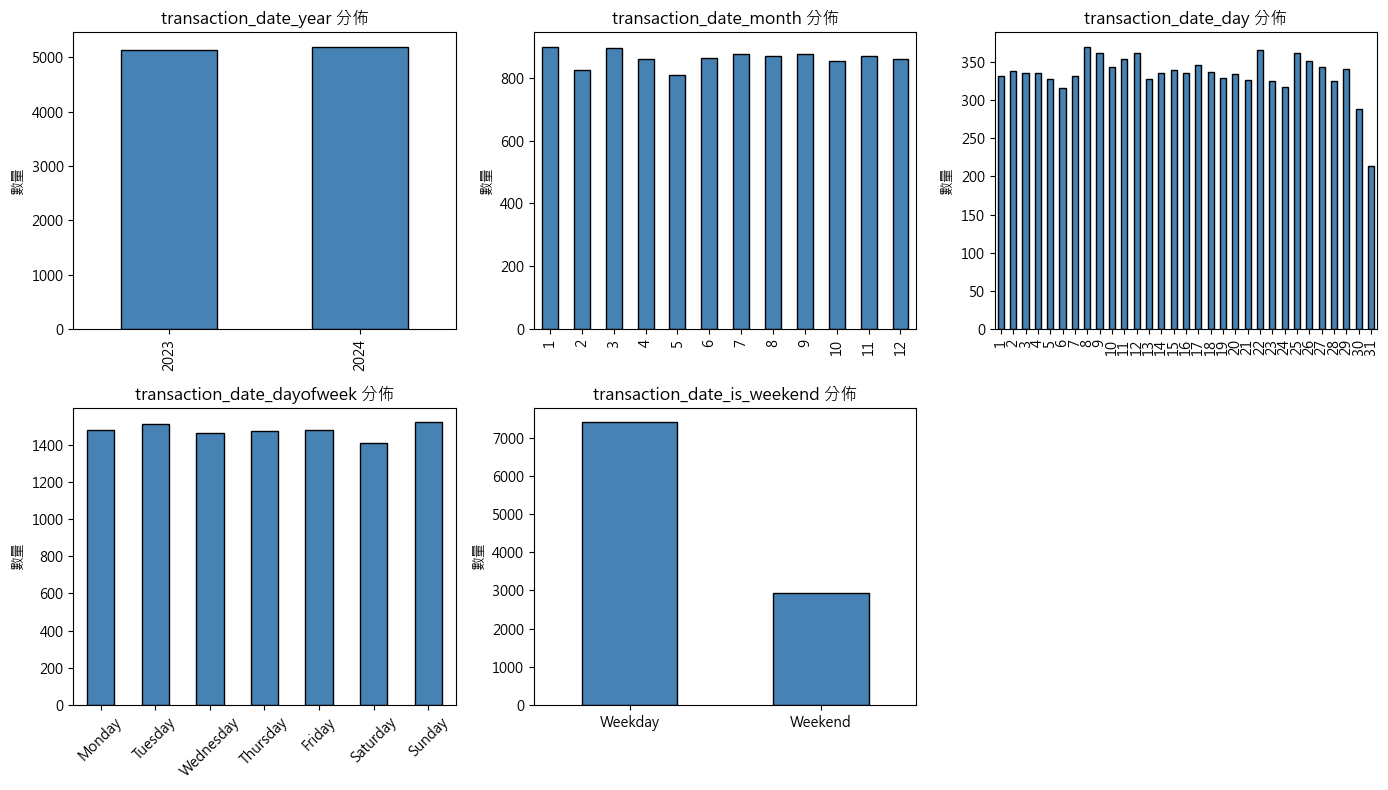

In [121]:
# 時間型 Interval 統計與特徵工程
print("=== 時間型 Interval 統計與特徵工程 ===")
for col in data_types['Interval']:
    if col in df.columns and col == 'transaction_date':  # 只處理 transaction_date
        print(f"\n{col}:")
        # 轉換為 datetime 如果還未轉換
        if df[col].dtype == 'object':
            df[col] = pd.to_datetime(df[col], errors='coerce')
        
        # 統計摘要
        print(f"  總數: {df[col].count()}")
        print(f"  開始時間: {df[col].min()}")
        print(f"  結束時間: {df[col].max()}")
        print(f"  時間跨度: {(df[col].max() - df[col].min()).days} 天")
        print(f"  缺失值: {df[col].isna().sum()}")
        
        # 時間特徵工程：提取年、月、日、星期幾、是否週末
        df[f'{col}_year'] = df[col].dt.year
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_day'] = df[col].dt.day
        df[f'{col}_dayofweek'] = df[col].dt.dayofweek  # 0=Monday, 6=Sunday
        df[f'{col}_is_weekend'] = df[col].dt.dayofweek.isin([5, 6]).astype(int)  # 1=Weekend, 0=Weekday
        
        print(f"\n  提取的特徵:")
        print(f"    - {col}_year")
        print(f"    - {col}_month")
        print(f"    - {col}_day")
        print(f"    - {col}_dayofweek (0=Monday, 6=Sunday)")
        print(f"    - {col}_is_weekend (1=Weekend, 0=Weekday)")
        
        # 各時間特徵的比例統計
        print(f"\n  各時間特徵比例:")
        
        # Year 比例
        print(f"\n    {col}_year:")
        year_counts = df[f'{col}_year'].value_counts().sort_index()
        total_count = len(df)
        for year, count in year_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {int(year)}: {count} ({percentage:.1f}%)")
        
        # Month 比例
        print(f"\n    {col}_month:")
        month_counts = df[f'{col}_month'].value_counts().sort_index()
        for month, count in month_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {int(month)}月: {count} ({percentage:.1f}%)")
        
        # Day of Week 比例
        print(f"\n    {col}_dayofweek:")
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        dow_counts = df[f'{col}_dayofweek'].value_counts().sort_index()
        for dow, count in dow_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {day_names[int(dow)]}: {count} ({percentage:.1f}%)")
        
        # Is Weekend 比例
        print(f"\n    {col}_is_weekend:")
        weekend_counts = df[f'{col}_is_weekend'].value_counts().sort_index()
        weekend_labels = ['Weekday', 'Weekend']
        for weekend, count in weekend_counts.items():
            percentage = (count / total_count) * 100
            print(f"      {weekend_labels[int(weekend)]}: {count} ({percentage:.1f}%)")
        
        # 繪製各特徵的分佈
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        
        # Year
        df[f'{col}_year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
        axes[0, 0].set_title(f'{col}_year 分佈')
        axes[0, 0].set_ylabel('數量')
        
        # Month
        df[f'{col}_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
        axes[0, 1].set_title(f'{col}_month 分佈')
        axes[0, 1].set_ylabel('數量')
        
        # Day
        df[f'{col}_day'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 2], color='steelblue', edgecolor='black')
        axes[0, 2].set_title(f'{col}_day 分佈')
        axes[0, 2].set_ylabel('數量')
        
        # Day of Week
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        df[f'{col}_dayofweek'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='black')
        axes[1, 0].set_title(f'{col}_dayofweek 分佈')
        axes[1, 0].set_ylabel('數量')
        axes[1, 0].set_xticklabels(day_names, rotation=45)
        
        # Is Weekend
        df[f'{col}_is_weekend'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='steelblue', edgecolor='black')
        axes[1, 1].set_title(f'{col}_is_weekend 分佈')
        axes[1, 1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
        axes[1, 1].set_ylabel('數量')
        
        # 隱藏最後一個子圖
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    elif col == 'transaction_date':
        pass  # 已處理
    else:
        print(f"非時間型 Interval 欄位 '{col}' 在其他地方處理")

=== Ratio 欄位統計 ===

age:


count    10345.000000
mean        38.559884
std         12.131789
min         18.000000
25%         28.000000
50%         39.000000
75%         49.000000
max         59.000000
Name: age, dtype: float64

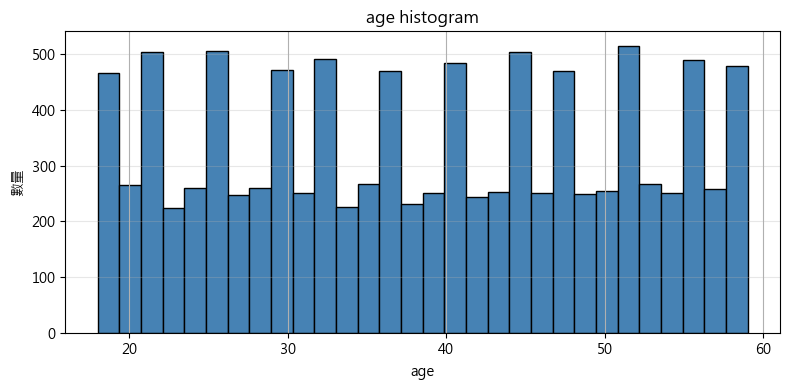


monthly_income:


count     10345.000000
mean      35053.381898
std       27084.517277
min        5000.000000
25%       12207.020000
50%       23800.520000
75%       55276.930000
max      145767.120000
Name: monthly_income, dtype: float64

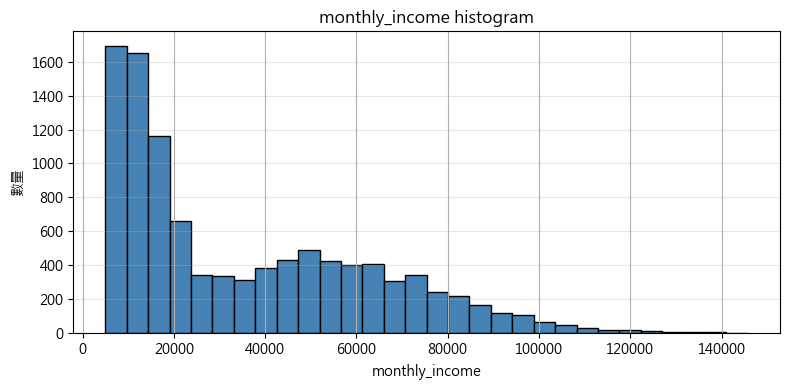


purchase_amount:


count    10345.000000
mean      3979.402721
std       1500.828483
min        100.000000
25%       2990.720000
50%       5000.000000
75%       5000.000000
max       5000.000000
Name: purchase_amount, dtype: float64

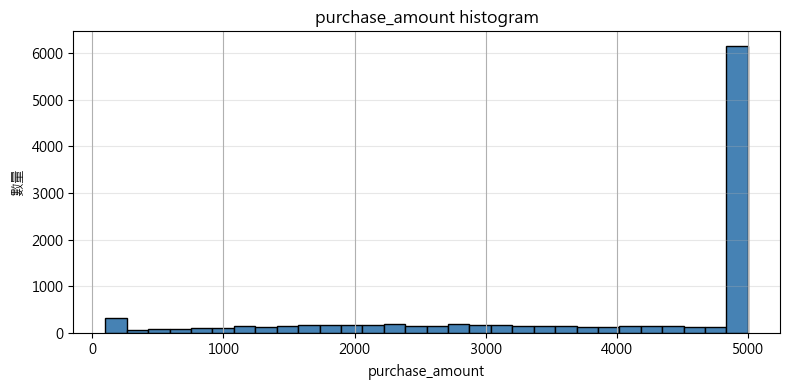


bnpl_installments:


count    10345.000000
mean         7.477525
std          3.362867
min          3.000000
25%          3.000000
50%          9.000000
75%          9.000000
max         12.000000
Name: bnpl_installments, dtype: float64

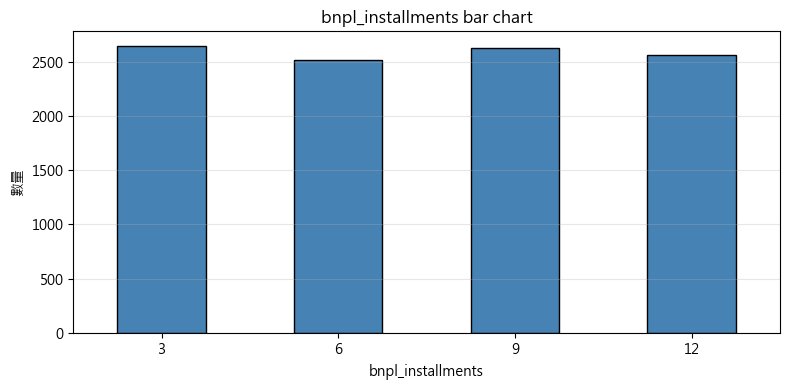


repayment_delay_days:


count    10345.000000
mean         8.742774
std          6.781849
min          0.000000
25%          2.000000
50%          9.000000
75%         14.000000
max         33.000000
Name: repayment_delay_days, dtype: float64

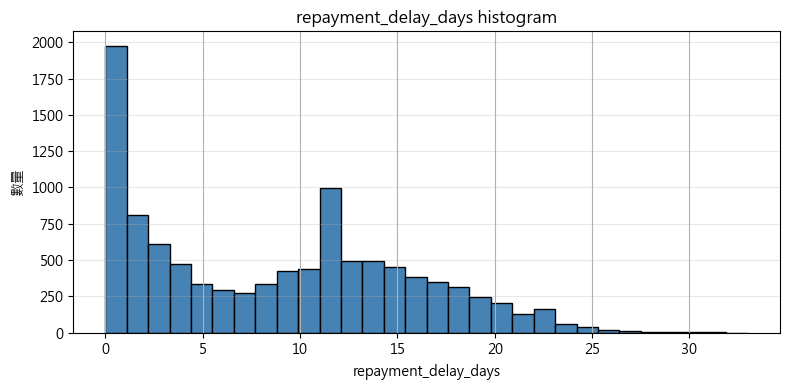


missed_payments:


count    10345.000000
mean         1.015950
std          0.996726
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: missed_payments, dtype: float64

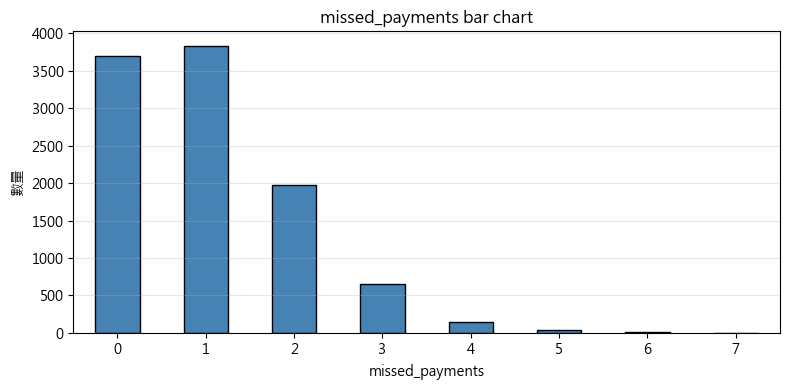


app_usage_frequency:


count    10345.000000
mean         5.524101
std          2.590364
min          1.000000
25%          3.300000
50%          5.550000
75%          7.750000
max         10.000000
Name: app_usage_frequency, dtype: float64

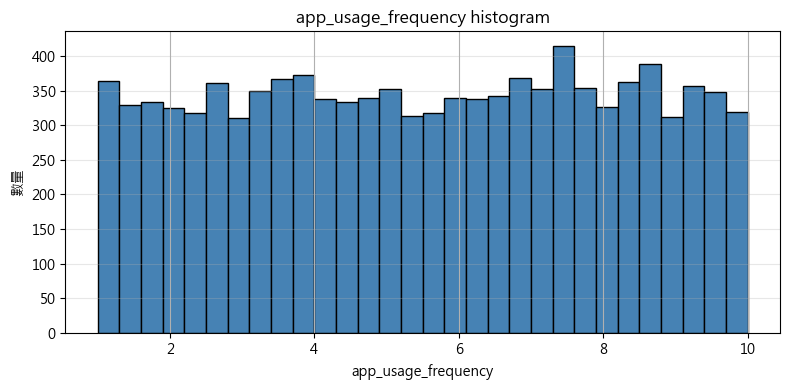


debt_to_income_ratio:


count    10345.000000
mean         0.181071
std          0.124887
min          0.000811
25%          0.080187
50%          0.138263
75%          0.268300
max          0.723460
Name: debt_to_income_ratio, dtype: float64

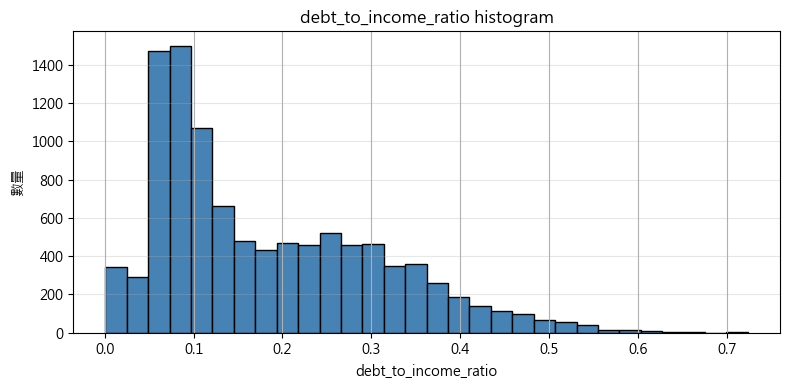


risk_score:


count    10345.000000
mean       198.534094
std         67.541384
min          0.000000
25%        153.600000
50%        202.800000
75%        250.800000
max        398.000000
Name: risk_score, dtype: float64

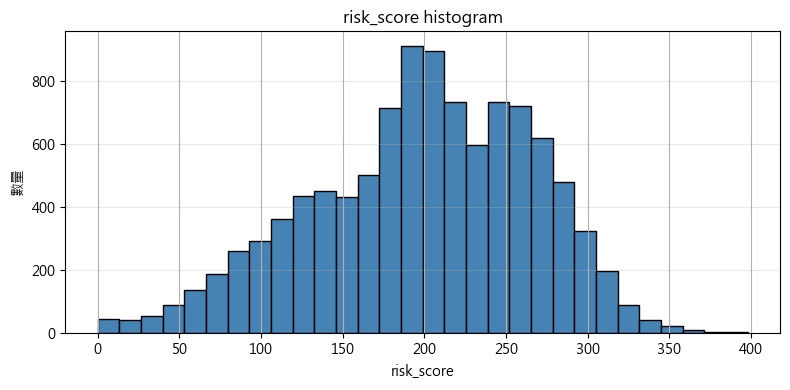

In [118]:
#Ratio統計
print("=== Ratio 欄位統計 ===")
for col in data_types['Ratio']:
    if col in df.columns:
        print(f"\n{col}:")
        display(df[col].describe().T)
        
        # 特殊處理：特定欄位使用長條圖
        if col in ['default_flag', 'missed_payments', 'bnpl_installments']:
            plt.figure(figsize=(8, 4))
            df[col].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
            plt.title(f"{col} bar chart")
            plt.xlabel(col)
            plt.ylabel('數量')
            plt.grid(axis='y', alpha=0.3)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            # 其他欄位使用直方圖
            plt.figure(figsize=(8, 4))
            df[col].hist(bins=30, color='steelblue', edgecolor='black')
            plt.title(f"{col} histogram")
            plt.xlabel(col)
            plt.ylabel('數量')
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

In [119]:
# 日期時間型欄位處理（已在上面 Interval 統計中完成）
print("=== 日期時間型欄位轉換完成 ===")
print(f"transaction_date 型態: {df['transaction_date'].dtype}")
print(f"時間範圍: {df['transaction_date'].min()} 到 {df['transaction_date'].max()}")
print(f"缺失值: {df['transaction_date'].isna().sum()}")

=== 相關係數分析 (One-Hot Encoding + Spearman) ===
進行 One-Hot Encoding 的欄位:
  - employment_type -> ['employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Student', 'employment_type_Unemployed']
  - product_category -> ['product_category_Beauty', 'product_category_Electronics', 'product_category_Fashion', 'product_category_Home', 'product_category_Sports']
  - location -> ['location_Australia', 'location_Canada', 'location_Germany', 'location_India', 'location_UK', 'location_USA']
  - default_flag -> ['default_flag_0', 'default_flag_1']
transaction_date (原始 datetime 列) 已移除，使用提取的時間特徵代替

分析的欄位 (31 個): ['age', 'monthly_income', 'credit_score', 'purchase_amount', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 'debt_to_income_ratio', 'risk_score', 'transaction_date_year', 'transaction_date_month', 'transaction_date_day', 'transaction_date_dayofweek', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Student

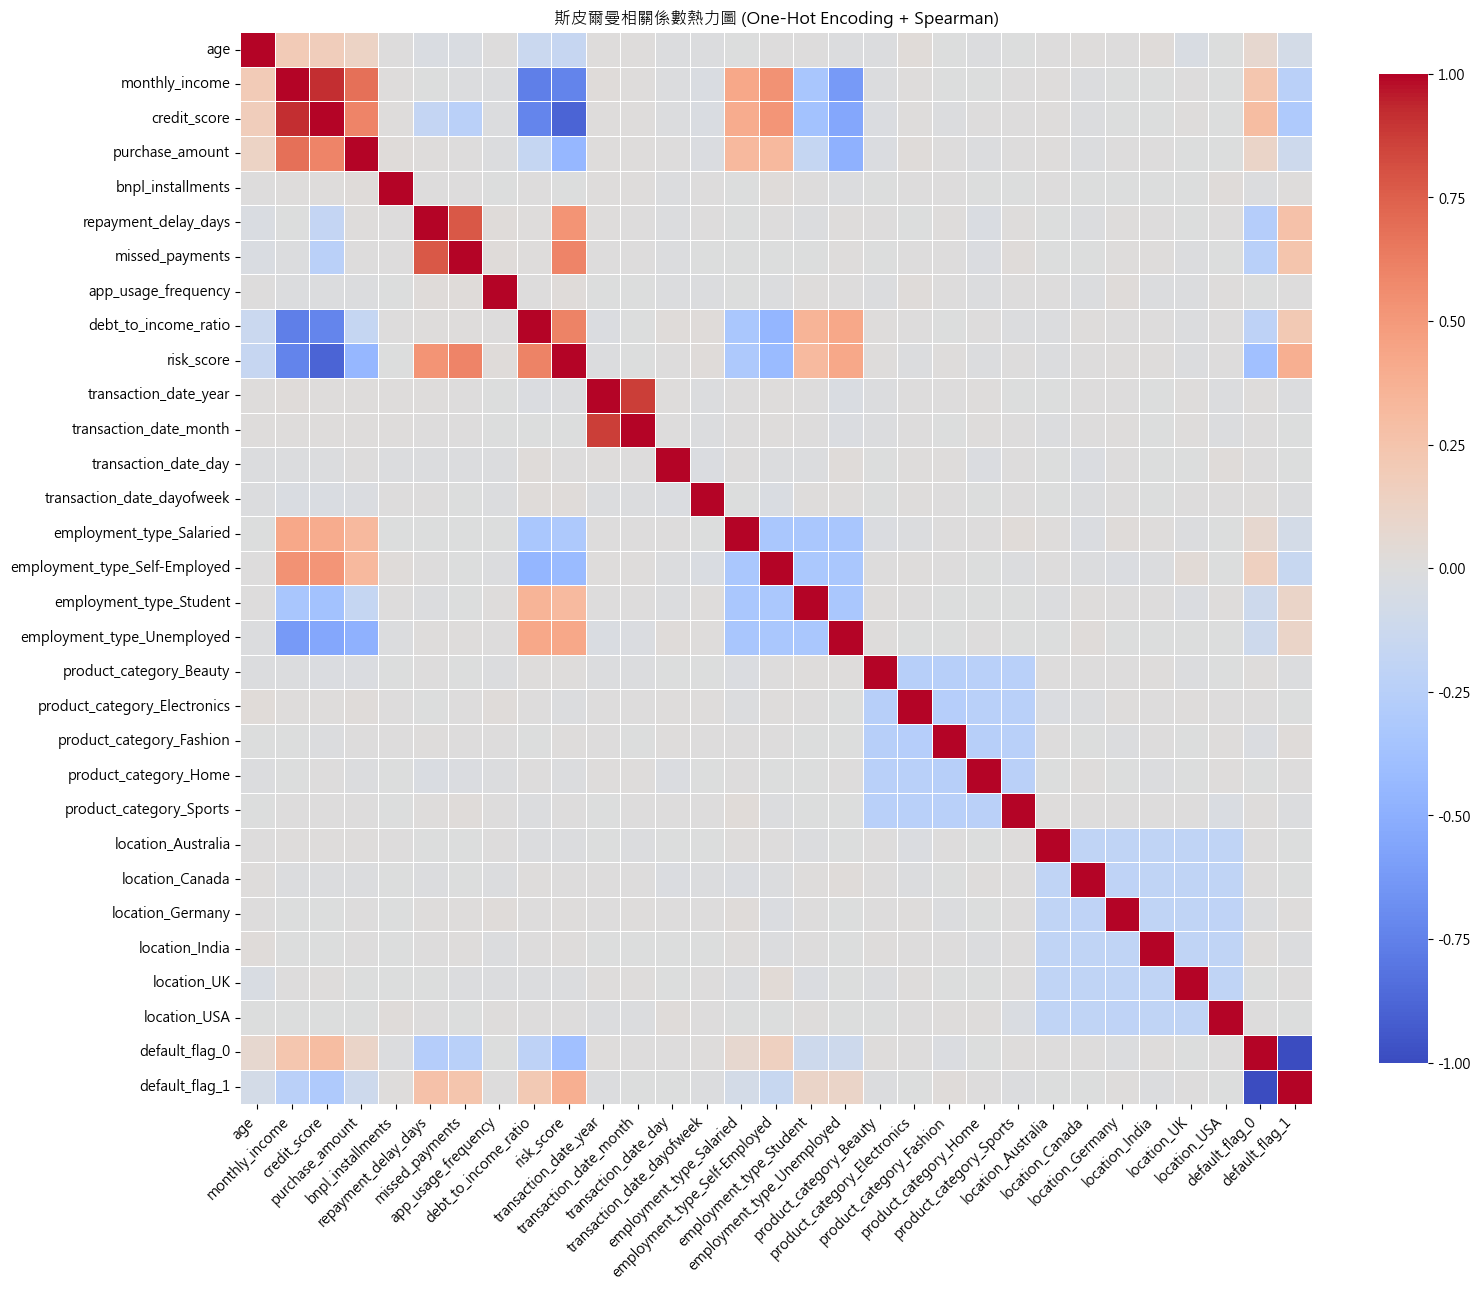


斯皮爾曼相關係數矩陣:


,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,app_usage_frequency,location,debt_to_income_ratio,risk_score,...,product_category_Home,product_category_Sports,location_Australia,location_Canada,location_Germany,location_India,location_UK,location_USA,default_flag_0,default_flag_1
age,1.000000,-0.002806,0.202487,0.175354,0.129444,-0.007275,0.006057,-0.027591,-0.025147,0.001979,-0.015363,-0.137650,-0.157483,...,-0.013920,-0.001619,0.003005,0.008533,0.005129,0.020235,-0.035007,-0.002452,0.075622,-0.075622
monthly_income,0.202487,-0.771652,1.000000,0.917798,0.683467,0.006728,0.008456,-0.005765,-0.009993,-0.010355,-0.001214,-0.763407,-0.735334,...,-0.004200,0.006733,0.013768,-0.015488,-0.002039,-0.000901,0.006960,-0.002115,0.242133,-0.242133
credit_score,0.175354,-0.725493,0.917798,1.000000,0.599005,0.011029,0.010397,-0.175262,-0.234733,-0.013410,-0.000867,-0.731247,-0.888907,...,0.006012,0.006164,0.010904,-0.009054,-0.003785,-0.005522,0.008264,-0.000620,0.302947,-0.302947
purchase_amount,0.129444,-0.563940,0.683467,0.599005,1.000000,0.003563,0.016228,0.008083,0.001119,-0.012417,-0.005721,-0.171407,-0.453112,...,-0.009679,0.003863,0.009861,-0.010090,0.002686,0.005304,-0.001137,-0.006603,0.115649,-0.115649
bnpl_installments,0.006057,-0.007763,0.008456,0.010397,0.016228,-0.005734,1.000000,0.006689,0.006454,-0.002730,0.007757,0.000850,-0.003048,...,-0.006830,-0.003775,0.003913,-0.006428,-0.005224,-0.005938,-0.002013,0.015686,-0.012234,0.012234
repayment_delay_days,-0.027591,0.007990,-0.005765,-0.175262,0.008083,-0.000588,0.006689,1.000000,0.774901,0.018086,0.007973,0.011994,0.528522,...,-0.024112,0.012817,-0.005464,-0.015567,0.013486,0.006632,-0.000411,0.001260,-0.269058,0.269058
missed_payments,-0.025147,0.009422,-0.009993,-0.234733,0.001119,0.003248,0.006454,0.774901,1.000000,0.019884,-0.001368,0.012274,0.597218,...,-0.023002,0.019299,-0.003102,-0.004607,0.008238,0.013182,-0.010752,-0.003153,-0.244009,0.244009
app_usage_frequency,0.001979,0.010415,-0.010355,-0.013410,-0.012417,-0.002718,-0.002730,0.018086,0.019884,1.000000,-0.001239,0.000793,0.018502,...,-0.011467,0.000900,0.006212,-0.010376,0.016967,-0.012906,-0.009587,0.009426,-0.004044,0.004044
debt_to_income_ratio,-0.137650,0.596579,-0.763407,-0.731247,-0.171407,-0.012678,0.000850,0.011994,0.012274,0.000793,-0.000111,1.000000,0.605571,...,0.002447,-0.013382,-0.013997,0.013218,0.006818,0.003667,-0.010540,0.000572,-0.214277,0.214277
risk_score,-0.157483,0.565818,-0.735334,-0.888907,-0.453112,-0.007114,-0.003048,0.528522,0.597218,0.018502,0.001304,0.605571,1.000000,...,-0.014099,0.001628,-0.011887,0.005736,0.008522,0.008289,-0.011825,0.000900,-0.386206,0.386206


In [120]:
# 相關係數分析
import seaborn as sns

print("=== 相關係數分析 (One-Hot Encoding + Spearman) ===")

# 建立一個複製的 dataframe 用於編碼
df_encoded = df.copy()

# One-Hot Encoding categorical 變數
categorical_cols = data_types['Categorical']
print("進行 One-Hot Encoding 的欄位:")
for col in categorical_cols:
    if col in df_encoded.columns:
        # 使用 pd.get_dummies 進行 One-Hot Encoding
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=False)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        df_encoded = df_encoded.drop(columns=[col])
        print(f"  - {col} -> {list(dummies.columns)}")

# 移除原始 datetime 欄位，保留提取的時間特徵
interval_cols = data_types['Interval']
for col in interval_cols:
    if col in df_encoded.columns and pd.api.types.is_datetime64_any_dtype(df_encoded[col]):
        # 刪除原始 datetime 列（不用於相關係數計算）
        df_encoded = df_encoded.drop(columns=[col])
        print(f"{col} (原始 datetime 列) 已移除，使用提取的時間特徵代替")

# 選擇所有可用的欄位進行相關係數分析
all_cols = df_encoded.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()

# 排除不適合相關係數分析的欄位，如 user_id
exclude_cols = ['user_id']
all_cols = [col for col in all_cols if col not in exclude_cols]

print(f"\n分析的欄位 ({len(all_cols)} 個): {all_cols}")

if all_cols:
    # 計算斯皮爾曼相關係數 (適合 One-Hot Encoding 的二元變數)
    spearman_corr = df_encoded[all_cols].corr(method='spearman')
    
    # 畫斯皮爾曼相關係數熱力圖
    plt.figure(figsize=(16, 14))
    sns.heatmap(spearman_corr, annot=False, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('斯皮爾曼相關係數熱力圖 (One-Hot Encoding + Spearman)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("\n斯皮爾曼相關係數矩陣:")
    display(spearman_corr)
else:
    print("沒有找到可分析的欄位。")

In [7]:
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("異常值 (Outlier) 檢測分析")
print("=" * 60)

# 定義要檢測異常值的欄位（數值型且有實際意義）
outlier_columns = ['age', 'monthly_income', 'credit_score', 'purchase_amount',
                   'repayment_delay_days', 'missed_payments', 'app_usage_frequency',
                   'debt_to_income_ratio', 'risk_score', 'bnpl_installments']

print(f"\n分析的欄位: {outlier_columns}")

# ============ 1. IQR 方法檢測異常值 ============
print("\n" + "=" * 60)
print("方法 1: 四分位距法 (IQR Method)")
print("=" * 60)

outliers_iqr = {}
outlier_counts_iqr = {}

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 找出異常值
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_iqr[col] = outlier_mask
    outlier_counts_iqr[col] = outlier_mask.sum()
    
    if outlier_counts_iqr[col] > 0:
        pct = (outlier_counts_iqr[col] / len(df)) * 100
        print(f"\n{col}:")
        print(f"  範圍: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  異常值數量: {outlier_counts_iqr[col]} ({pct:.2f}%)")
        print(f"  異常值範圍: [{df.loc[outlier_mask, col].min():.2f}, {df.loc[outlier_mask, col].max():.2f}]")

# ============ 2. Z-score 方法 ============
print("\n" + "=" * 60)
print("方法 2: Z-score 方法 (閾值: |z| > 3)")
print("=" * 60)

outliers_zscore = {}
outlier_counts_zscore = {}

for col in outlier_columns:
    z_scores = np.abs(stats.zscore(df[col]))
    outlier_mask = z_scores > 3
    outliers_zscore[col] = outlier_mask
    outlier_counts_zscore[col] = outlier_mask.sum()
    
    if outlier_counts_zscore[col] > 0:
        pct = (outlier_counts_zscore[col] / len(df)) * 100
        print(f"\n{col}:")
        print(f"  異常值數量: {outlier_counts_zscore[col]} ({pct:.2f}%)")
        print(f"  最大 Z-score: {z_scores.max():.2f}")

# ============ 3. 隔離森林 (Isolation Forest) ============
print("\n" + "=" * 60)
print("方法 3: 隔離森林 (Isolation Forest)")
print("=" * 60)

# 準備數據
X = df[outlier_columns].copy()

# 應用隔離森林
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_predictions = iso_forest.fit_predict(X)
outlier_mask_if = outlier_predictions == -1

outlier_count_if = outlier_mask_if.sum()
pct_if = (outlier_count_if / len(df)) * 100

print(f"\n異常值數量: {outlier_count_if} ({pct_if:.2f}%)")
print(f"正常值數量: {(~outlier_mask_if).sum()} ({100 - pct_if:.2f}%)")

# ============ 4. 局部離群因子 (LOF) ============
print("\n" + "=" * 60)
print("方法 4: 局部離群因子 (Local Outlier Factor)")
print("=" * 60)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_predictions_lof = lof.fit_predict(X)
outlier_mask_lof = outlier_predictions_lof == -1

outlier_count_lof = outlier_mask_lof.sum()
pct_lof = (outlier_count_lof / len(df)) * 100

print(f"\n異常值數量: {outlier_count_lof} ({pct_lof:.2f}%)")
print(f"正常值數量: {(~outlier_mask_lof).sum()} ({100 - pct_lof:.2f}%)")

# ============ 5. 綜合異常值檢測 ============
print("\n" + "=" * 60)
print("異常值檢測方法比較總結")
print("=" * 60)

summary_data = {
    '方法': ['IQR (平均)', 'Z-score', '隔離森林', 'LOF'],
    '異常值數量': [
        sum(outlier_counts_iqr.values()),
        sum(outlier_counts_zscore.values()),
        outlier_count_if,
        outlier_count_lof
    ],
    '異常值百分比': [
        f"{(sum(outlier_counts_iqr.values()) / len(df)) * 100:.2f}%",
        f"{(sum(outlier_counts_zscore.values()) / len(df)) * 100:.2f}%",
        f"{pct_if:.2f}%",
        f"{pct_lof:.2f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n")
display(summary_df)

異常值 (Outlier) 檢測分析

分析的欄位: ['age', 'monthly_income', 'credit_score', 'purchase_amount', 'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 'debt_to_income_ratio', 'risk_score', 'bnpl_installments']

方法 1: 四分位距法 (IQR Method)

monthly_income:
  範圍: [-52397.85, 119881.80]
  異常值數量: 25 (0.24%)
  異常值範圍: [119935.82, 145767.12]

repayment_delay_days:
  範圍: [-16.00, 32.00]
  異常值數量: 1 (0.01%)
  異常值範圍: [33.00, 33.00]

missed_payments:
  範圍: [-3.00, 5.00]
  異常值數量: 8 (0.08%)
  異常值範圍: [6.00, 7.00]

debt_to_income_ratio:
  範圍: [-0.20, 0.55]
  異常值數量: 57 (0.55%)
  異常值範圍: [0.55, 0.72]

risk_score:
  範圍: [7.80, 396.60]
  異常值數量: 31 (0.30%)
  異常值範圍: [0.00, 398.00]

方法 2: Z-score 方法 (閾值: |z| > 3)

monthly_income:
  異常值數量: 38 (0.37%)
  最大 Z-score: 4.09

repayment_delay_days:
  異常值數量: 7 (0.07%)
  最大 Z-score: 3.58

missed_payments:
  異常值數量: 39 (0.38%)
  最大 Z-score: 6.00

debt_to_income_ratio:
  異常值數量: 51 (0.49%)
  最大 Z-score: 4.34

方法 3: 隔離森林 (Isolation Forest)

異常值數量: 518 (5.01%)
正常值數量: 9827 (9

,方法,異常值數量,異常值百分比
0,IQR (平均),122,1.18%
1,Z-score,135,1.30%
2,隔離森林,518,5.01%
3,LOF,518,5.01%


## 異常值 (Outlier) 探索與檢測

異常值是指明顯偏離其他數據點的值。有多種方法可以檢測異常值：
1. **四分位距法 (IQR)**：基於四分位數，適合用於有明確分布的數據
2. **Z-score 法**：衡量數據點距離平均值的標準差距離
3. **隔離森林 (Isolation Forest)**：機器學習方法，適合高維數據
4. **Local Outlier Factor (LOF)**：基於局部密度的異常值檢測

在信貸風險數據中，異常值可能表示：
- 異常的收入或消費行為
- 不尋常的延遲或違約情況
- 數據輸入錯誤


異常值可視化 - Box Plot


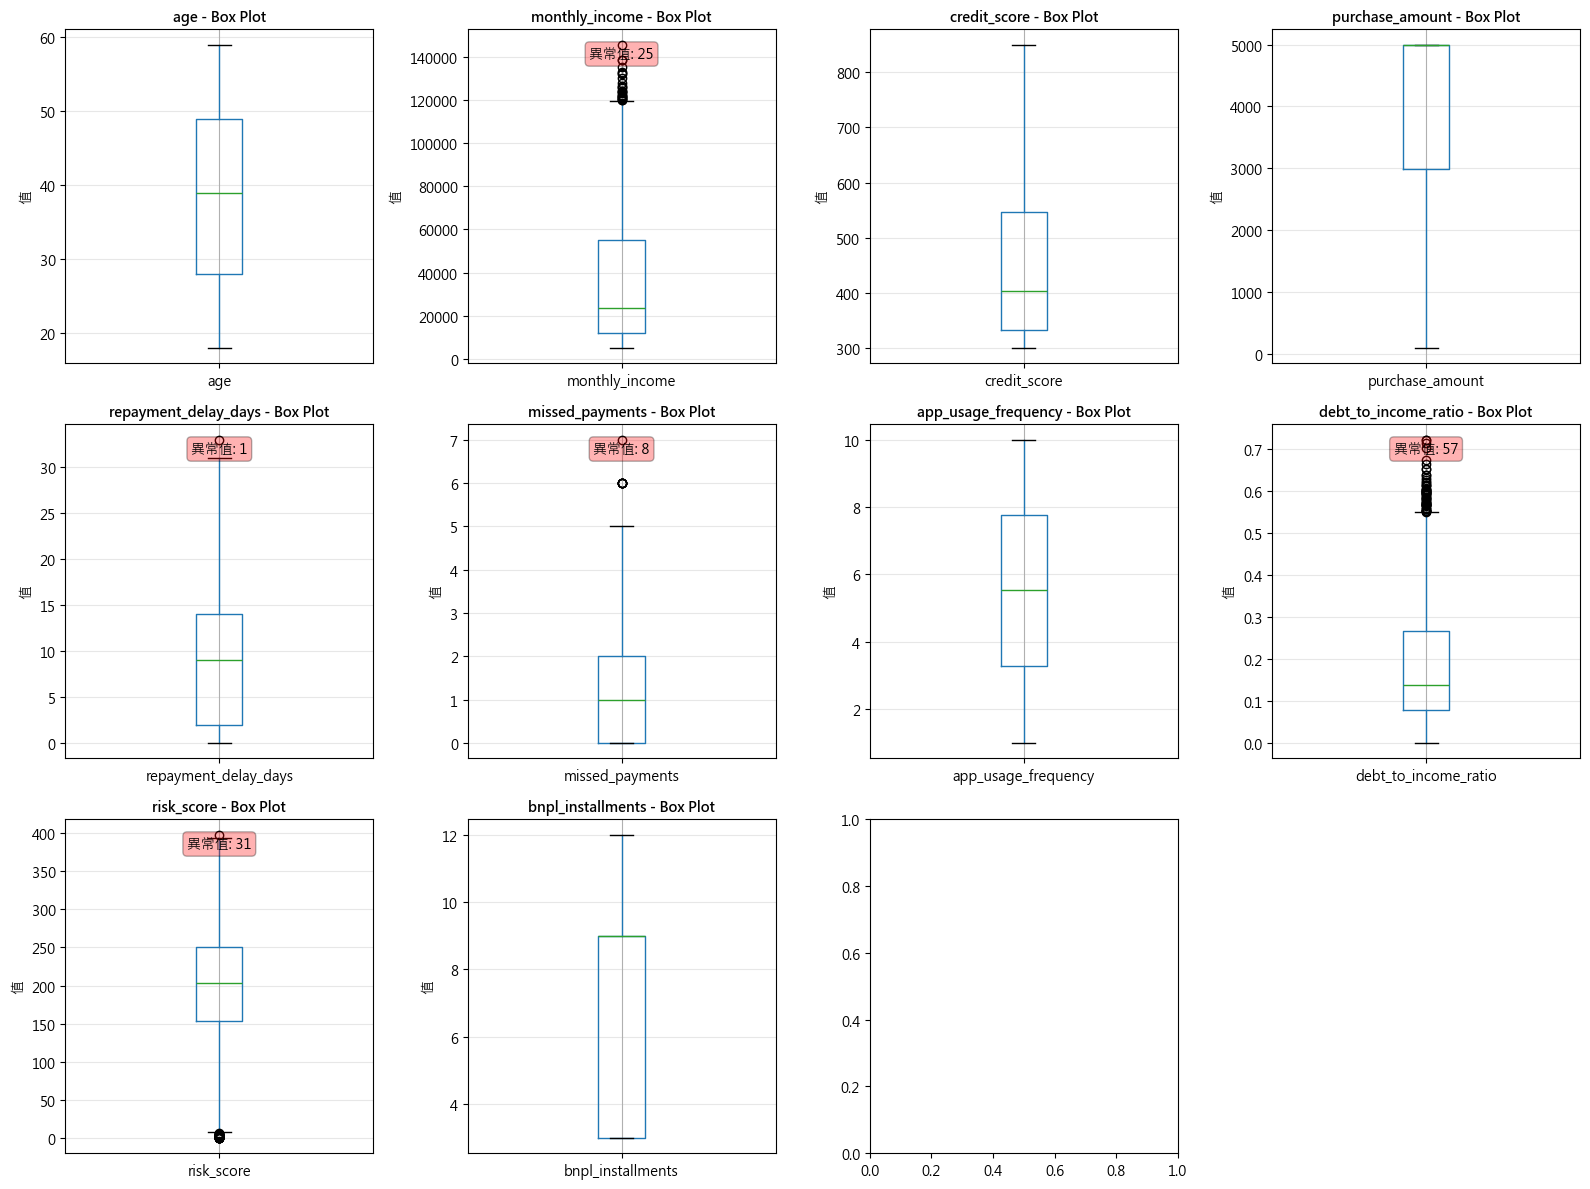


✅ Box Plot 顯示了各欄位中的異常值


In [8]:
print("=" * 60)
print("異常值可視化 - Box Plot")
print("=" * 60)

# 繪製 Box Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(outlier_columns):
    ax = axes[idx]
    df.boxplot(column=col, ax=ax)
    ax.set_title(f"{col} - Box Plot", fontsize=10, fontweight='bold')
    ax.set_ylabel('值')
    ax.grid(axis='y', alpha=0.3)
    
    # 標記異常值數量
    outlier_count = outlier_counts_iqr.get(col, 0)
    if outlier_count > 0:
        ax.text(0.5, 0.95, f"異常值: {outlier_count}", 
                transform=ax.transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

# 隱藏最後一個子圖
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Box Plot 顯示了各欄位中的異常值")

## 異常值可視化

使用 Box Plot 可以直觀地看出異常值的分佈。Box plot 顯示：
- 中間的線：中位數 (median)
- 方框：四分位距 (IQR)，包含 50% 的數據
- 鬚線：正常範圍的邊界
- 圓點：超出鬚線的異常值
